In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

In [2]:
def oracle(mask, qc, n):
    rev_mask = mask[::-1]

    # copy input to ancilla
    for i in range(n):
        qc.cx(i, n+1)

    # find key to make pairs
    m = rev_mask.find("1")

    if m != -1:
        # devide cloud into two parts (m=0 and m=1) and XOR only m=1
        for i in range(n):
            if rev_mask[i] == "1":
                qc.cx(m, n+i)

    qc.barrier()
    return qc

In [3]:
def build_circuit(mask):
    n = len(mask)
    qc = QuantumCircuit(2*n, n)

    qc.h(range(n))
    qc.barrier()

    oracle_circuit = oracle(mask, qc, n)
    qc.compose(oracle_circuit, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))
    
    return qc

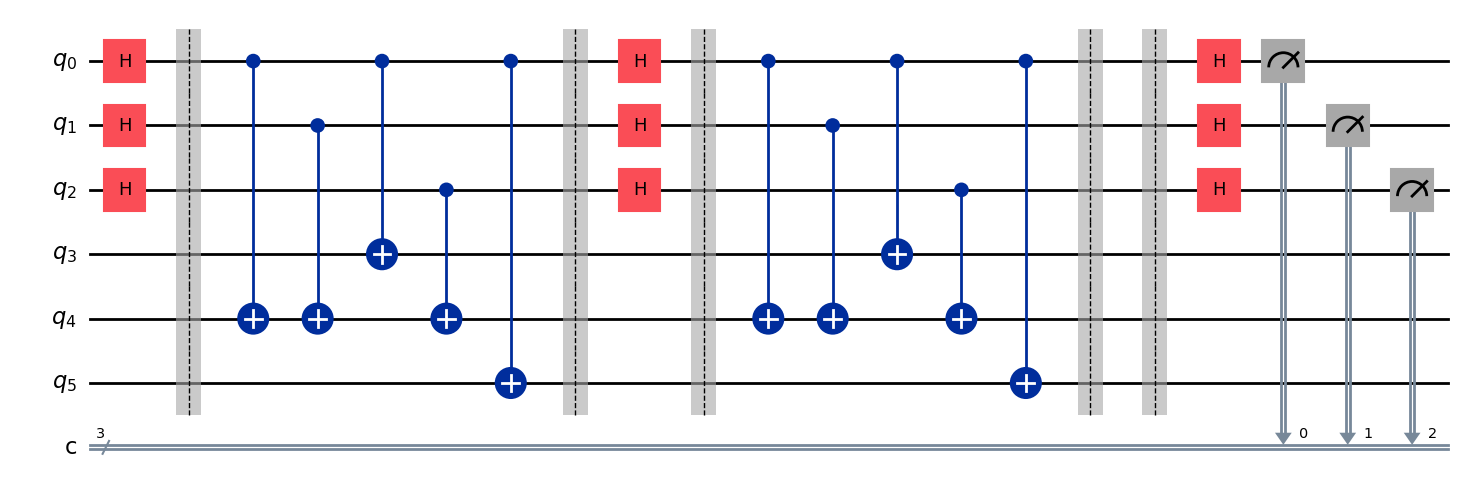

In [4]:
qc = build_circuit("101")
display(qc.draw('mpl'))

In [11]:
def run_circuit(mask):
    circuit = build_circuit(mask)
    simulator = Aer.get_backend("qasm_simulator")
    compiled = transpile(circuit, simulator)
    job = simulator.run(compiled, shots=1024)
    result = job.result()
    counts = result.get_counts()
    print(f"Mask: {mask}")
    print(f"Results: {list(counts.keys())}")

    for y_str in counts:
        dot_product = sum(int(y_bit) * int(s_bit) for y_bit, s_bit in zip(y_str[::-1], mask[::-1]))
        print(f"Result {y_str}: scalar product mod 2 = {dot_product % 2}")

    return counts

results = run_circuit("110")

Mask: 110
Results: ['001', '110', '100', '011', '111', '000', '010', '101']
Result 001: scalar product mod 2 = 0
Result 110: scalar product mod 2 = 0
Result 100: scalar product mod 2 = 1
Result 011: scalar product mod 2 = 1
Result 111: scalar product mod 2 = 0
Result 000: scalar product mod 2 = 0
Result 010: scalar product mod 2 = 1
Result 101: scalar product mod 2 = 1
